In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import io
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error



In [2]:
df = pd.read_csv("GTA 5 Vehicle Data Export.csv")


In [3]:
df.head()

,Rank,Vehicle Name,Manufacturer,Vehicle Class,Price (GTA$),Top Speed (mph),Lap Time (Seconds),DLC / Release Update
0,1,Krieger,Benefactor,Super,"$2,875,000",127.25,0:59.27,Diamond Casino
1,2,Emerus,Progen,Super,"$2,750,000",127.25,0:58.29,Diamond Casino
2,3,Itali GTO,Grotti,Sports,"$1,965,000",127.75,0:59.72,Arena War
3,4,Buffalo EVX,Bravado,Muscle,"$2,140,000",124.50,1:03.46,San Andreas Mercs
4,5,Vagner,Dewbauchee,Super,"$1,535,000",126.75,0:59.19,Gunrunning


In [4]:
df.tail()

,Rank,Vehicle Name,Manufacturer,Vehicle Class,Price (GTA$),Top Speed (mph),Lap Time (Seconds),DLC / Release Update
45,46,Raiju,Mammoth,Plane,"$6,850,000",232.00,NaN,San Andreas Mercs
46,47,B-11 Strikeforce,B-11,Plane,"$3,800,000",163.75,NaN,After Hours
47,48,Pyro,Buckingham,Plane,"$4,450,000",222.75,NaN,Smuggler's Run
48,49,Hydra,Mammoth,Plane,"$3,990,000",209.25,NaN,Heists Update
49,50,P-996 Lazer,JoBuilt,Plane,"$6,500,000",195.00,NaN,Base Game


In [5]:
df.sample()

,Rank,Vehicle Name,Manufacturer,Vehicle Class,Price (GTA$),Top Speed (mph),Lap Time (Seconds),DLC / Release Update
38,39,Hakuchou Drag,Shitzu,Motorcycle,"$976,000",126.5,0:57.50,Bikers Update


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50 entries, 0 to 49
Data columns (total 8 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Rank                  50 non-null     int64  
 1   Vehicle Name          50 non-null     object 
 2   Manufacturer          50 non-null     object 
 3   Vehicle Class         50 non-null     object 
 4   Price (GTA$)          50 non-null     object 
 5   Top Speed (mph)       50 non-null     float64
 6   Lap Time (Seconds)    39 non-null     object 
 7   DLC / Release Update  50 non-null     object 
dtypes: float64(1), int64(1), object(6)
memory usage: 3.3+ KB


In [7]:
df.describe

<bound method NDFrame.describe of     Rank       Vehicle Name Manufacturer Vehicle Class Price (GTA$)  \
0      1            Krieger   Benefactor         Super   $2,875,000   
1      2             Emerus       Progen         Super   $2,750,000   
2      3          Itali GTO       Grotti        Sports   $1,965,000   
3      4        Buffalo EVX      Bravado        Muscle   $2,140,000   
4      5             Vagner   Dewbauchee         Super   $1,535,000   
5      6             Pariah       Ocelot        Sports   $1,420,000   
6      7    Hao's S95 (HSW)        Karin        Sports   $1,995,000   
7      8             Virtue       Ocelot         Super   $2,980,000   
8      9          Torero XO      Pegassi         Super   $2,890,000   
9     10              Niobe    Ubermacht        Sports   $1,880,000   
10    11              Batur         Enus         Super   $3,200,000   
11    12          Vigero ZX     Declasse        Muscle   $1,947,000   
12    13     GTO Stinger TT       Grotti   

In [8]:
df.describe()

,Rank,Top Speed (mph)
count,50.00000,50.000000
mean,25.50000,133.251000
std,14.57738,31.283652
min,1.00000,30.000000
25%,13.25000,122.437500
50%,25.50000,126.625000
75%,37.75000,134.250000
max,50.00000,232.000000


In [9]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
Rank,50.0,25.500,14.577380,1.0,13.2500,25.500,37.75,50.0
Top Speed (mph),50.0,133.251,31.283652,30.0,122.4375,126.625,134.25,232.0


In [10]:
df.shape

(50, 8)

In [11]:
print(df.dtypes)

Rank                      int64
Vehicle Name             object
Manufacturer             object
Vehicle Class            object
Price (GTA$)             object
Top Speed (mph)         float64
Lap Time (Seconds)       object
DLC / Release Update     object
dtype: object


In [12]:
df.dtypes.T

Rank                      int64
Vehicle Name             object
Manufacturer             object
Vehicle Class            object
Price (GTA$)             object
Top Speed (mph)         float64
Lap Time (Seconds)       object
DLC / Release Update     object
dtype: object

In [13]:
df.index

RangeIndex(start=0, stop=50, step=1)

In [14]:
df.columns

Index(['Rank', 'Vehicle Name', 'Manufacturer', 'Vehicle Class', 'Price (GTA$)',
       'Top Speed (mph)', 'Lap Time (Seconds)', 'DLC / Release Update'],
      dtype='object')

In [15]:
df['Price'] = df['Price (GTA$)'].astype(str).str.replace('$', '').str.replace(',', '')
df['Price'] = pd.to_numeric(df['Price'])


In [16]:
df = df.dropna(subset=['Price', 'Top Speed (mph)'])


In [17]:
X = df['Price'].values.reshape(-1, 1)
y = df['Top Speed (mph)'].values

In [18]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"Training Data Size: {len(X_train)}")
print(f"Testing Data Size: {len(X_test)}")


Training Data Size: 40
Testing Data Size: 10


In [19]:
print("\n SKLEARN IMPLEMENTATION ---")

# Initialize and Fit
model = LinearRegression()
model.fit(X_train, y_train)

# Predict
y_pred_sklearn = model.predict(X_test)

# Evaluate
mse_sklearn = mean_squared_error(y_test, y_pred_sklearn)

print(f"Sklearn Slope (m): {model.coef_[0]:.6f}")
print(f"Sklearn Intercept (c): {model.intercept_:.4f}")
print(f"Sklearn MSE: {mse_sklearn:.4f}")


 SKLEARN IMPLEMENTATION ---
Sklearn Slope (m): 0.000015
Sklearn Intercept (c): 93.1591
Sklearn MSE: 1841.3470


In [20]:
print("\n  MANUAL IMPLEMENTATION ---")

# Flatten X_train for manual math (1D array)
x_vals = X_train.flatten()
y_vals = y_train

n = len(x_vals)

# Calculate Sums
sum_x = np.sum(x_vals)
sum_y = np.sum(y_vals)
sum_xy = np.sum(x_vals * y_vals)
sum_x2 = np.sum(x_vals ** 2)

# Calculate Slope (m)
numerator = (n * sum_xy) - (sum_x * sum_y)
denominator = (n * sum_x2) - (sum_x ** 2)
m_manual = numerator / denominator

# Calculate Intercept (c)
c_manual = (sum_y - (m_manual * sum_x)) / n

# Predict on Test Data Manually
y_pred_manual = (m_manual * X_test.flatten()) + c_manual

# Calculate MSE Manually
mse_manual = np.mean((y_test - y_pred_manual) ** 2)

print(f"Manual Slope (m): {m_manual:.6f}")
print(f"Manual Intercept (c): {c_manual:.4f}")
print(f"Manual MSE: {mse_manual:.4f}")


  MANUAL IMPLEMENTATION ---
Manual Slope (m): 0.000015
Manual Intercept (c): 93.1591
Manual MSE: 1841.3470



--- COMPARISON ---
Difference in MSE: 0.0000000000
Note: The values should be nearly identical.

Results exported to 'gta_vehicle_regression_results.csv'


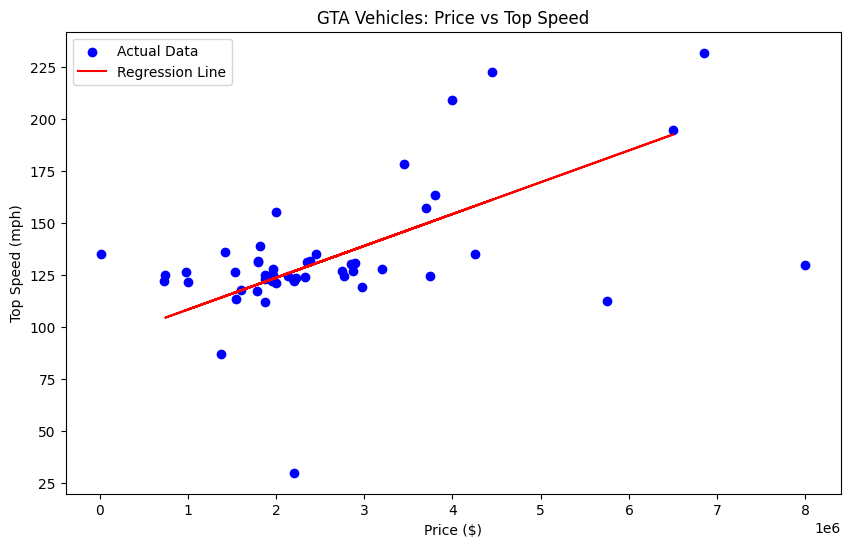

In [21]:
print("\n--- COMPARISON ---")
print(f"Difference in MSE: {abs(mse_sklearn - mse_manual):.10f}")
print("Note: The values should be nearly identical.")

# Save results to CSV for your project submission
results = pd.DataFrame({
    'Actual Top Speed': y_test,
    'Predicted Speed (Sklearn)': y_pred_sklearn,
    'Predicted Speed (Manual)': y_pred_manual
})
results.to_csv("gta_vehicle_regression_results.csv", index=False)
print("\nResults exported to 'gta_vehicle_regression_results.csv'")

# Optional: Plotting to visualize
plt.figure(figsize=(10, 6))
plt.scatter(X, y, color='blue', label='Actual Data')
plt.plot(X_train, m_manual * X_train + c_manual, color='red', label='Regression Line')
plt.title('GTA Vehicles: Price vs Top Speed')
plt.xlabel('Price ($)')
plt.ylabel('Top Speed (mph)')
plt.legend()
plt.show()